<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/CURRENT_most_recent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS Lab2 - Assignment 2: Price Predictions - regression models with PyTorch**

Please make sure you use the software versions specified in this notebook, rather than the latest or other versions.

In this assignment you will use the skills you have acquired in weeks 6 and 7 to build and test several different regression models with the aim of predicting AirBnB prices. Using your experience so far, together with Pandas and PyTorch, you will have sufficient tools to build both a linear regression model and a simple neural net. You will implement careful data-cleaning, experiment with feature extraction, and fine-tune hyperparameters to evaluate the performance of each model, improving predictions where possible, and suggesting the best strategies for a model with higher predictive accuracy.
 \\



 **BEFORE YOU START - we will use Google Colab's GPU capabilities in this assignment. So, in the top right-hand corner next to the "RAM" and "Disk" icons click the drop-down arrow and click "change runtime type" - then select "T4 GPU".** \\



---



 Work through this notebook adding the parts of code required to achieve each objective, and compile the results into a 1-page report describing your analysis. As you work through the notebook you will find some prompts have been provided in the code cells to get you started. You may refer back to the material provided in labs. Throughout the notebook you will also find 'Report Instructions' advising you what to include in your write-up. \\



Be careful to answer all parts of the questions and read the text prompts carefully in the code cells and the markdown cells. Please provide your code for each part of the exercise in the same box as the question, and do not edit any of the comments already provided. \\



You are encouraged to add your own comments, and marks will be awarded for appropriately and carefully commented code. Please preface each of your comments with ###YOUR_INITIALS. e.g. if your name is John Smith:

`###JS: plot histogram using the .hist() method`



**Dataset Description:**

We will continue to work with the Manchester listing dataset for this assignment. The dataset includes details such as host information, property features, reviews, and availability. Make sure the file is copied from CANVAS to your Google drive before attempting the problem set.

*   File 1: Manchester_AirBnB_detailed_listings.csv

**To Submit:**

1.   **This notebook containing your code and visualizations**
      - Please name the file "YOUR_NAME_DSLab2_a2.ipynb" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be in .ipynb format - markers will check that your code runs successfully.

2.   **1-page report summarising your work and findings**
      - Please name the file "YOUR_NAME_DSLab2_a2_report.pdf" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be submitted in PDF format - LaTEX is recommended to generate your report, but you will not be penalised for a well-presented Word document exported as a PDF.
      - Please aim to provide your full report on 1 side of A4 (marks will be lost for reports less than 1 side of A4 or for reports greater than 2 sides of A4, e.g. plots which overflow to the second side are allowed and will not be penalised.)


A total of 50 marks are available for completing the exercises

A total of 50 marks are available for completing the report instructions and producing a high-quality report (5 marks for presentation and 5 marks for quality of analysis)

# Setup

The following blocks of code are provided to set up your notebook.

In [1]:
# CodeGrade Tag Init1
## Mount your Google Drive so we can access the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## Importing PyTorch and Pandas
import torch
import pandas as pd
import matplotlib.pylab as plt

In [3]:
## Checking PyTorch version
print("PyTorch version:", torch.__version__)


PyTorch version: 2.10.0+cu128


## Load Data

In [4]:
# CodeGrade Tag Init2
file_path = "/content/Manchester_AirBnB_detailed_listings.csv"
df = pd.read_csv(file_path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6135 entries, 0 to 6134
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6135 non-null   int64  
 1   listing_url                                   6135 non-null   object 
 2   scrape_id                                     6135 non-null   int64  
 3   last_scraped                                  6135 non-null   object 
 4   source                                        6135 non-null   object 
 5   name                                          6135 non-null   object 
 6   description                                   0 non-null      float64
 7   neighborhood_overview                         3105 non-null   object 
 8   picture_url                                   6135 non-null   object 
 9   host_id                                       6135 non-null   i

# Q1 - Data Cleaning
**10 marks available for completing exercises 1.1, 1.2 & 1.3** \\
**No report instructions for Q1**

**Exercise 1.1 (8 marks)**

We have worked extensively in the labs with "cleaning" or pre-processing datafiles before running our analysis. Drawing on the skills you have gained,
create a function below to clean an incoming .csv file. Assume that the .csv has already been read into a dataframe called "df" (e.g. like the one above!) that will form the input for your function. The skeleton of the function is provided for you, and contains instructions for how to complete it.  \\


**Apply the following cuts:**

**1.**   For a column named "price" remove any special characters e.g. '$' or '£' \\

**2.**   Convert all columns of Dtype = Object (**except** for columns 'room_type', 'neighbourhood_cleansed', and 'bathrooms_text') into Dtype 'Float'. Set the error-handling to = 'coerce' \\

**3.**   NaN/Null value handling 1: Some columns will consist of many NaN/NULL values, whereas other may only contain a few. First, compute how many NaN/Null values are in the 'price' column, and then remove any column that contains a larger number of NaN/Null values than this.\\

**4.**   Apply a price cut to the dataframe such that only prices less than your chosen value are included. (The price cut value should be passed in as a parameter and applied within the function) \\

**5.**   NaNs/Null value handling 2: finally, remove any remaining NaNs from the full dataframe \\

**Save the cleaned dataframe** to a .csv file called "Manchester_AirBnB_detailed_listings_clean.csv"



In [6]:
# CodeGrade Tag Q1a

import numpy as np

def prepdata(df, pricecut):

  ## Remove '$' symbol from 'price' column and convert to numerical value
  ## YOUR ANSWER HERE
  df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype(float)

  ## Convert most Object columns to numeric, but keep hold of
  ## 'room_type', 'neighbourhood_cleansed' and 'bathrooms_text' because we will need them
  ## Begin by selecting all the columns you want to convert:
  ## YOUR ANSWER HERE
  columns_to_convert = df.select_dtypes(include = ['object']).columns.drop(['room_type', 'neighbourhood_cleansed', 'bathrooms_text'])

  ## Convert these columns to floats and coerce the errors:
  ## YOUR ANSWER HERE
  df[columns_to_convert] = df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

  ## This means we'll have some columns now of type float etc but full of NaNs
  ## Let's see how many values remain in the price column
  ## e.g. N_non_null_prices =
  ## YOUR ANSWER HERE
  N_non_null_checkin = df['review_scores_checkin'].count()

  ## Select columns with more NaNs than this, and append their names to a list called "cols_to_chuck"
  ## YOUR ANSWER HERE
  cols_to_chuck = []
  for name, non_null in zip(df.columns, df.count()):
    if non_null < N_non_null_checkin:
      cols_to_chuck.append(name)

  ## Drop these specific columns
  ## YOUR ANSWER HERE
  df.drop(columns = cols_to_chuck, inplace = True)

  ## Apply price cut that has been passed in as a parameter called "pricecut"
  ## YOUR ANSWER HERE
  df = df[df['price'] < pricecut]

  ## Drop any last sneaky NaNs
  ## YOUR ANSWER HERE
  df = df.dropna()

  ## Write out the dataframe to a file called "Manchester_AirBnB_detailed_listings_clean.csv"
  ## YOUR ANSWER HERE
  df.to_csv('/content/Manchester_AirBnB_detailed_listings_clean.csv', index=False)



**Exercise 1.2 (1 mark)**

Call the function by passing it our dataframe "df", and apply a pricecut to generate the new datafile. A recommended pricecut would be in the range 200 - 300 GBP (or dollars etc).

In [7]:
# CodeGrade Tag Q1b
## YOUR ANSWER HERE

prepdata(df, 200)

**Exercise 1.3 (1 mark)**

Load your new csv file into a pandas dataframe called clean_df. Display the first few lines of the dataframe to check the contents look sensible. Show the full list of column names and their data types.

In [8]:
# CodeGrade Tag Q1c
## Load data from your newly prepared CSV file using pandas
## YOUR ANSWER HERE

clean_df = pd.read_csv('/content/Manchester_AirBnB_detailed_listings_clean.csv')

In [9]:
# CodeGrade Tag Q1d
## Show first few lines
## YOUR ANSWER HERE

clean_df.head()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,766050787596406053,20231223055521,486290053,17,20,Gorton South,53.446580,-2.19012,Private room,2,...,0,5.00,5.00,4.50,4.50,4.50,17,2,15,0
1,847143003204121734,20231223055521,419859842,9,19,Salford District,53.480290,-2.26835,Entire home/apt,3,...,2,4.67,4.33,4.78,4.89,4.11,9,6,2,1
2,5544328,20231223055521,26836949,23,31,Salford District,53.484530,-2.25691,Entire home/apt,4,...,0,5.00,4.80,4.87,4.93,4.67,6,6,0,0
3,42147825,20231223055521,86393358,3,9,Salford District,53.502200,-2.26850,Private room,2,...,0,4.65,4.88,4.88,4.94,4.65,3,0,3,0
4,995685793625080683,20231223055521,518896546,2,2,Salford District,53.475031,-2.27219,Private room,2,...,0,5.00,5.00,5.00,5.00,5.00,2,0,2,0


In [9]:
# CodeGrade Tag Q1e
## List columns and their Dtypes
## YOUR ANSWER HERE

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4053 entries, 0 to 4052
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4053 non-null   int64  
 1   scrape_id                                     4053 non-null   int64  
 2   host_id                                       4053 non-null   int64  
 3   host_listings_count                           4053 non-null   int64  
 4   host_total_listings_count                     4053 non-null   int64  
 5   neighbourhood_cleansed                        4053 non-null   object 
 6   latitude                                      4053 non-null   float64
 7   longitude                                     4053 non-null   float64
 8   room_type                                     4053 non-null   object 
 9   accommodates                                  4053 non-null   i

Check that it looks as you expect. e.g. There should be only 3 Object columns remaining.

# Q2 - Linear Regression on numerical data
**10 marks available for completing exercises 2.1 & 2.2** \\
**12 marks available for following report instructions 2.1 & 2.2**



**Exercise 2.1 (8 marks)**

We'll begin with a simple linear regression model. Below are step-by-step instructions for setting up the model. Use the lab material so far to help you fill in the gaps.

In [10]:
# CodeGrade Tag Init3
## Some imports have already been made to help you
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


Begin by removing categorical data from the dataframe so that we deal only with numerical values for now (see week 6 and 7 material)

In [11]:
# CodeGrade Tag Q2a
## Drop categorical variables from the DataFrame
## YOUR ANSWER HERE

clean_df = clean_df.select_dtypes(exclude='category')

In [12]:
# CodeGrade Tag Q2b
## Drop any NaNs from the df
## YOUR ANSWER HERE

clean_df = clean_df.dropna()

Define features and target variable:

In [13]:
# CodeGrade Tag Q2c
## X = the full dataframe except for the label column (remember: the label is the variable we want to predict...)
## YOUR ANSWER HERE

X = clean_df.drop('price', axis=1)

In [14]:
# CodeGrade Tag Q2d
## y = The dataframe column containing our "label" data
## YOUR ANSWER HERE

y = clean_df['price']

In [15]:
# CodeGrade Tag Q2e
## Split the df into training and testing sets
## You will probably want to use the 'train_test_split' function
## YOUR ANSWER HERE

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

Pre-processing

In [16]:
# Define preprocessing steps for numerical features (provided)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

In [17]:
# CodeGrade Tag Q2f
## Set up a small pre-processing pipeline called "numeric_transformer"
## For now we only want to scale the data,
## so create a pipeline with a single step: applying the StandardScaler
## YOUR ANSWER HERE

numeric_transformer = Pipeline(steps = [
    ('scaler', StandardScaler())
])

In [18]:
## Next we need to transform the columns using the numeric transformer
## You will need to use the "ColumnTransformer" function
## Apply a single transformation: the numeric transformer!
## (Provided)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ])


In [19]:
## Preprocess the df (provided)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

X_val_preprocessed = preprocessor.transform(X_val)

Construct PyTorch tensors

In [20]:
## Convert preprocessed df to PyTorch tensors (provided)
X_train_tensor = torch.tensor(X_train_preprocessed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_preprocessed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

#CA :validation too (delete if unnecessary)
X_val_tensor = torch.tensor(X_val_preprocessed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

Setup Linear Regression model and loss function

In [21]:
## Define the linear regression model (provided)
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


In [22]:
## Instantiate the linear regression model (provided)
input_dim = X_train_tensor.shape[1]
linear_regression_model = LinearRegressionModel(input_dim)


In [23]:
## Define loss function and optimization algorithm (provided)
criterion = nn.MSELoss()
optimizer = optim.Adam(linear_regression_model.parameters(), lr=0.1)


Model Training

In [24]:
## Train the model (provided)

train_losses=[]
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = linear_regression_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    ## Track training loss
    train_losses.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')



Epoch [100/1000], Loss: 7334.5146
Epoch [200/1000], Loss: 5867.3311
Epoch [300/1000], Loss: 4731.5103
Epoch [400/1000], Loss: 3817.4204
Epoch [500/1000], Loss: 3089.7048
Epoch [600/1000], Loss: 2521.0327
Epoch [700/1000], Loss: 2085.8435
Epoch [800/1000], Loss: 1760.3866
Epoch [900/1000], Loss: 1523.0466
Epoch [1000/1000], Loss: 1354.6394


In [25]:
## Evaluate the model (provided)
with torch.no_grad():
    predicted_prices = linear_regression_model(X_test_tensor)
    test_loss = criterion(predicted_prices, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')


Test Loss: 1214.1395


**Report instructions 2.1 (6 marks)**

What was the loss for the final iteration of the training data? What was the value of the test loss? Explain what the test loss is, and why it may differ from the final iteration of the train loss. \\

**Exercise 2.2 (2 marks)**

Create a plot below to visualise the success (or not) of this model for predicting airbnb price.

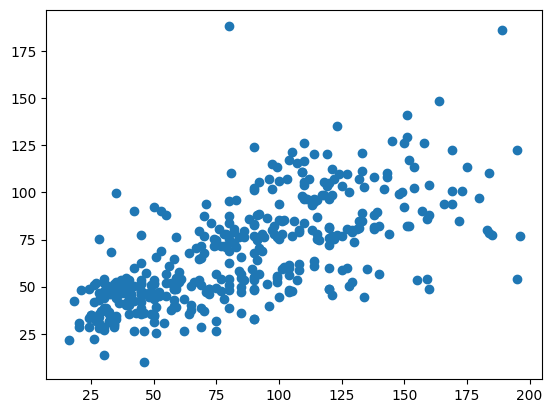

In [26]:
# CodeGrade Tag Q2g
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

## Convert tensors to numpy arrays
## YOUR ANSWER HERE
predictions = predicted_prices.numpy()
actual = y_test_tensor.numpy()

## Create plot (don't forget labels!!)
## YOUR ANSWER HERE
plt.scatter(actual, predictions)
plt.show()

**Report Instructions 2.2 (6 marks)**

The training-loss curve for the above model behaves as shown below. Explain in your report what the training curve is. Ideally what should a training curve look like? Examine the training-loss curve shown below - what does it imply about the model we have trained above?

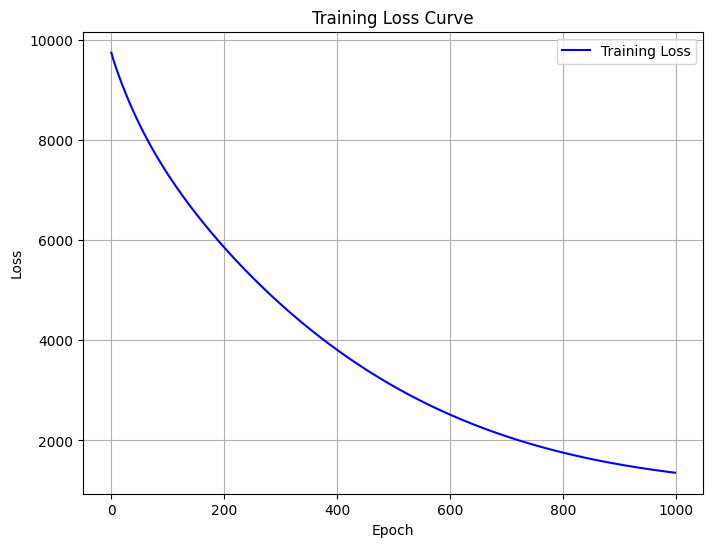

In [27]:
## provided
## Training loss curve
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

# Q3 - Using Categorical Data in Linear Regression
**15 marks available for completing exercises 3.1, 3.2, 3.3 & 3.4** \\
**11 marks available for following report instructions 3.1 & 3.2**



**Exercise 3.1 (10 marks)**

Below is the outline of a function to combine most of the steps we applied above, but now also incorporating categorical data. Use your experience so far in labs to help you fill in the blanks, you might like to have the material from weeks 6 and 7 to hand. \\

The function takes an input as described below allowing you to update the categorical columns of interest and alter hyperparameters to investigate the effect.



```
def model(df,     ## the dataframe of interest (dataframe object)
 label,           ## column name of the target variable (str)
 cat_cols,        ## list of categorical column names format: ['str', 'str', etc...]
 learning_rate,   ## step size at which the model parameters are updated during training (float)
 epochs,          ## number of iterations (float)
 plots=True):     ## generate useful plots unless explicitly asked not to
```





In [28]:
# CodeGrade Tag Q3a
def model(df, label, cat_cols, learning_rate, epochs, plots=True):

  df = df.dropna()

  ## Define features and target variable
  ## YOUR ANSWER HERE
  y = df[label]
  X = df.drop(label, axis=1)

  ## Split the data into training and testing sets
  ## YOUR ANSWER HERE
  X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2)
  X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp)

  ## Define preprocessing steps for numerical and categorical features
  ## YOUR ANSWER HERE
  #CA: scaling numericals
  numeric_features = X.select_dtypes(include = ['float64', 'int64']).columns
  scale_pipe = Pipeline(steps = [
      ('scaler', StandardScaler())
  ])

  #CA: encoding categoricals
  onehot_pipe = Pipeline(steps = [
      ('onehot', OneHotEncoder())
  ])

  preprocessor = ColumnTransformer(
      transformers = [
        ('scaler', scale_pipe, numeric_features),
        ('onehot', onehot_pipe, cat_cols)
      ])

  ## Preprocess the data
  ## YOUR ANSWER HERE
  X_train_preprocessed = preprocessor.fit_transform(X_train)
  X_test_preprocessed = preprocessor.transform(X_test)

  X_val_preprocessed = preprocessor.transform(X_val)

  ## Convert preprocessed data to PyTorch tensors
  ## YOUR ANSWER HERE
  X_train_tensor = torch.tensor(X_train_preprocessed, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).reshape(-1, 1)
  X_test_tensor = torch.tensor(X_test_preprocessed, dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)
  X_val_tensor = torch.tensor(X_val_preprocessed, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

  ## Define the linear regression model (provided)
  class LinearRegressionModel(nn.Module):
      def __init__(self, input_dim):
          super(LinearRegressionModel, self).__init__()
          self.linear = nn.Linear(input_dim, 1)

      def forward(self, x):
          return self.linear(x)

  ## Instantiate the linear regression model
  ## YOUR ANSWER HERE

  input_dim = X_train_tensor.shape[1]
  linear_regression_model = LinearRegressionModel(input_dim)

  ## Define loss function and optimization algorithm
  ## YOUR ANSWER HERE
  criterion = nn.MSELoss()
  optimizer = optim.Adam(linear_regression_model.parameters(), lr=learning_rate)

  ## Train the model
  ## YOUR ANSWER HERE
  train_losses = []
  for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = linear_regression_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch+1) % 100 == 0:
      print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    #CA: val_losses calculation
    #linear_regression_model.eval()
    val_losses = []
    #val_loss = 0.0

    val_outputs = linear_regression_model(X_test_tensor)
    vloss = criterion(val_outputs, y_test_tensor)
    val_losses.append(vloss.detach())

  ## Evaluate the model
  ## YOUR ANSWER HERE
  with torch.no_grad():
    predicted_prices = linear_regression_model(X_test_tensor)
    test_loss = criterion(predicted_prices, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

  if plots==True:

      ## Convert tensors to numpy arrays
      ## YOUR ANSWER HERE
      predicted_prices = predicted_prices.numpy()
      actual_prices = y_test_tensor.numpy()

      ## Create scatter plot (provided)
      plt.figure(figsize=(8, 6))
      plt.scatter(actual_prices, predicted_prices, alpha=0.3, c='k')
      plt.plot([min(actual_prices), max(actual_prices)], [min(actual_prices), max(actual_prices)], color='red', linestyle='--')
      plt.xlabel('Actual Prices')
      plt.ylabel('Predicted Prices')
      plt.title('Predicted vs. Actual Prices')
      plt.grid(True)
      plt.show()

      ## Training and validation loss curve (provided)
      plt.figure(figsize=(8, 6))
      plt.plot(train_losses, label='Training Loss', color='k')
      plt.plot(val_losses, label='Validation Loss', color='orange')
      plt.xlabel('Epoch')
      plt.ylabel('Loss')
      plt.title('Training and Validation Loss Curve')
      plt.legend()
      plt.grid(True)
      plt.show()

      #CA: print val_losses
      print(val_outputs)
      print(vloss.item())
      print(val_losses)

**Exercise 3.2 (1 mark)**

Call the 'model' function and pass in the 'room type' categorical feature. Set the learning rate to 0.1, and use 1000 epochs (i.e. the same as before).

In [29]:
def model(df, label, cat_cols, learning_rate, epochs, plots=True):

  val_losses = []

  df = df.dropna()

  ## Define features and target variable
  ## YOUR ANSWER HERE
  y = df['price']
  X = df.drop('price', axis = 1)

  ## Split the data into training and testing sets
  ## YOUR ANSWER HERE
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

  ## Define preprocessing steps for numerical and categorical features
  ## YOUR ANSWER HERE
  scale_pipe = Pipeline(steps = [
      ('scaler', StandardScaler())
  ])
  #CA: numerical features
  #changed to X train 15:14
  numerical_feats = X.select_dtypes(include=['float64', 'int64']).columns
  cat_pipe = Pipeline(steps = [
      ('onehot', OneHotEncoder( handle_unknown='ignore'))
  ])
  ## Preprocess the data
  ## YOUR ANSWER HERE
  #CA: combining into a single preprocessing pipe
  preprocessor = ColumnTransformer(
      transformers = [
          ('scaler', scale_pipe, numerical_feats),
          ('onehot', cat_pipe, cat_cols)
      ])
  X_train_preprocessed = preprocessor.fit_transform(X_train)
  X_test_preprocessed = preprocessor.transform(X_test)

  ## Convert preprocessed data to PyTorch tensors
  ## YOUR ANSWER HERE
  X_train_tensor = torch.tensor(X_train_preprocessed, dtype=torch.float32)
  X_test_tensor = torch.tensor(X_test_preprocessed,dtype=torch.float32)
  #array to column vector (1 dim to 2)
  y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
  y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).reshape(-1, 1)

  ## Define the linear regression model (provided)
  class LinearRegressionModel(nn.Module):
      def __init__(self, input_dim):
          super(LinearRegressionModel, self).__init__()
          self.linear = nn.Linear(input_dim, 1)

      def forward(self, x):
          return self.linear(x)

  ## Instantiate the linear regression model
  ## YOUR ANSWER HERE
  #CA: get input dimension first

  input_dim = X_train_tensor.shape[1]    #num of columns !!!
  print(f"Input dimension:  , {input_dim}")

  linreg = LinearRegressionModel(input_dim)

  ## Define loss function and optimization algorithm
  ## YOUR ANSWER HERE
  loss_criterion = nn.MSELoss()
  optimizer = optim.Adam(linreg.parameters(), lr=0.1)

  ## Train the model
  ## YOUR ANSWER HERE
  training_losses = []
  epochs = 1000
  for epoch in range(epochs):
    optimizer.zero_grad()
    #CA: clears gradients for refining in loop
    outputs = linreg(X_train_tensor)
    loss = loss_criterion(outputs, y_train_tensor)
    #CA: gradient is adapted via backward pass
    loss.backward()
    optimizer.step()
    ## Track training loss
    training_losses.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    linreg.eval()

    #CA: validation data

    val_pred = linreg(X_test_tensor)
    val_loss = criterion(val_pred, y_test_tensor)
    val_losses.append(val_loss.detach())

  ## Evaluate the model
  ## YOUR ANSWER HERE
  #CA: 'detaches' gradients that no longer needed
  with torch.no_grad():
    predicted_prices = linreg(X_test_tensor)
    test_loss = loss_criterion(predicted_prices, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')



  if plots==True:

      ## Convert tensors to numpy arrays
      ## YOUR ANSWER HERE
      pred_price= predicted_prices.numpy()
      #CA: data that is 'actual' is y test... passed to learn from errors
      actual_prices = y_test_tensor.numpy()

      ## Create scatter plot (provided)
      plt.figure(figsize=(8, 6))
      plt.scatter(actual_prices, pred_price, alpha=0.3, c='k')
      plt.plot([min(actual_prices), max(actual_prices)], [min(actual_prices), max(actual_prices)], color='red', linestyle='--')
      plt.xlabel('Actual Prices')
      plt.ylabel('Predicted Prices')
      plt.title('Predicted vs. Actual Prices')
      plt.grid(True)
      plt.show()

      ## Training and validation loss curve (provided)
      plt.figure(figsize=(8, 6))
      plt.plot(train_losses, label='Training Loss', color='k')
      plt.plot(val_losses, label='Validation Loss', color='orange')
      plt.xlabel('Epoch')
      plt.ylabel('Loss')
      plt.title('Training and Validation Loss Curve')
      plt.legend()
      plt.grid(True)
      plt.show()

Input dimension:  , 37
Epoch [100/1000], Loss: 5979.1562
Epoch [200/1000], Loss: 3847.8638
Epoch [300/1000], Loss: 2550.4070
Epoch [400/1000], Loss: 1790.6547
Epoch [500/1000], Loss: 1372.1733
Epoch [600/1000], Loss: 1152.2080
Epoch [700/1000], Loss: 1037.3092
Epoch [800/1000], Loss: 974.0475
Epoch [900/1000], Loss: 935.5577
Epoch [1000/1000], Loss: 909.6463
Test Loss: 924.3063


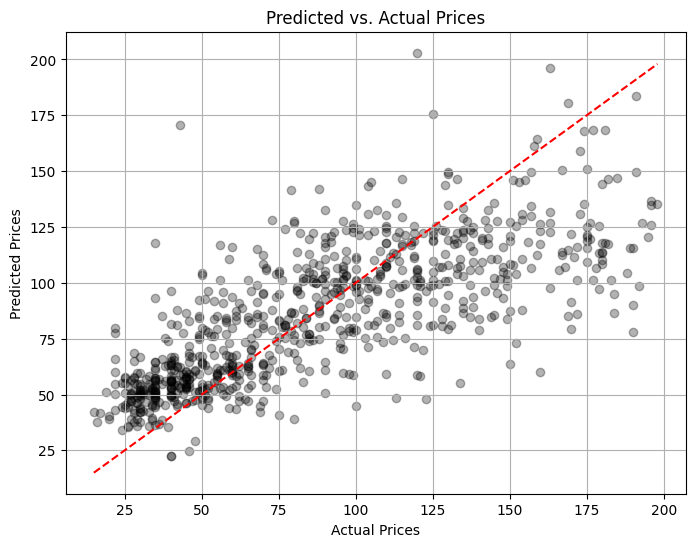

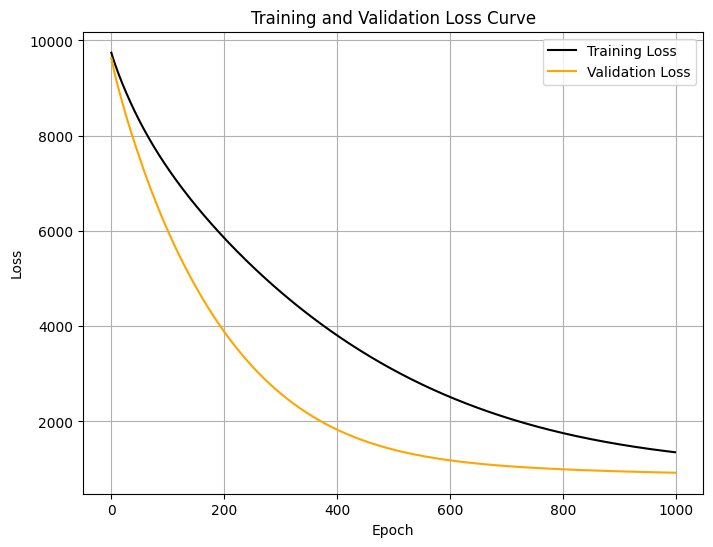

In [30]:
# CodeGrade Tag Q3b
## YOUR ANSWER HERE

model(clean_df, 'price', ['room_type'], learning_rate=0.1, epochs=1000, plots=True)

**Report Instructions 3.1 (2 marks)**

How did including the 'room_type' categorical variable alter the value of 'Test Loss'?

**Exercise 3.3 (3 marks)**

Next, keeping epochs = 1000, systematically alter the learning rate to to the following values and note the affect on "Test Loss" and the training loss curve.

1.   learning_rate= 0.01
2.   learning_rate= 0.5
3.   learning_rate= 0.05



Input dimension:  , 37
Epoch [100/1000], Loss: 5920.2861
Epoch [200/1000], Loss: 3803.8538
Epoch [300/1000], Loss: 2528.9790
Epoch [400/1000], Loss: 1787.1011
Epoch [500/1000], Loss: 1378.7545
Epoch [600/1000], Loss: 1162.0736
Epoch [700/1000], Loss: 1045.9976
Epoch [800/1000], Loss: 979.6240
Epoch [900/1000], Loss: 937.8804
Epoch [1000/1000], Loss: 909.4297
Test Loss: 892.8677


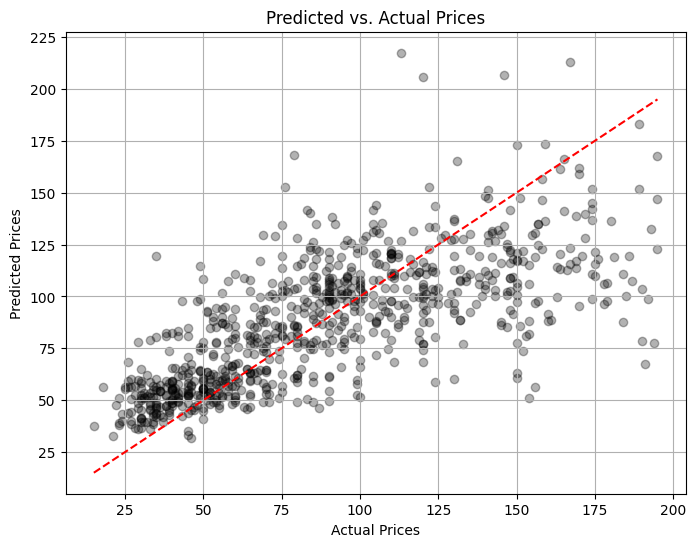

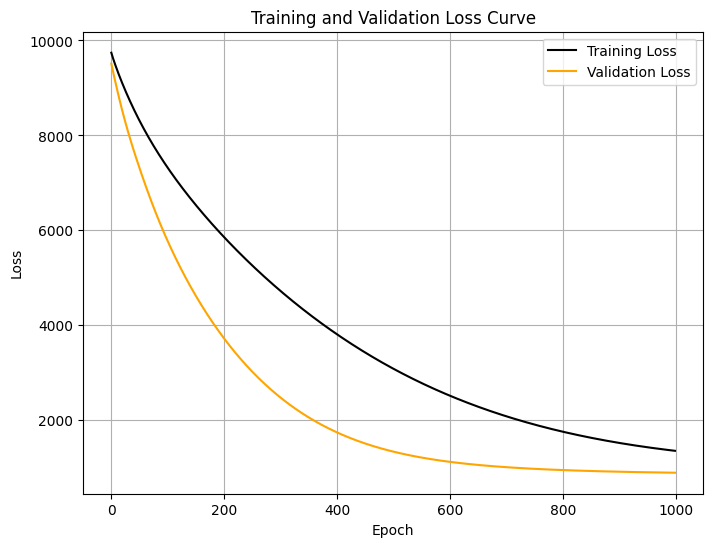

In [31]:
# CodeGrade Tag Q3c
## YOUR ANSWER HERE

model(clean_df, 'price', ['room_type'], learning_rate=0.01, epochs=1000, plots=True)

Input dimension:  , 37
Epoch [100/1000], Loss: 5973.3740
Epoch [200/1000], Loss: 3833.1460
Epoch [300/1000], Loss: 2536.0425
Epoch [400/1000], Loss: 1777.7761
Epoch [500/1000], Loss: 1360.0338
Epoch [600/1000], Loss: 1140.0214
Epoch [700/1000], Loss: 1024.6992
Epoch [800/1000], Loss: 961.0518
Epoch [900/1000], Loss: 922.4178
Epoch [1000/1000], Loss: 896.6063
Test Loss: 967.4360


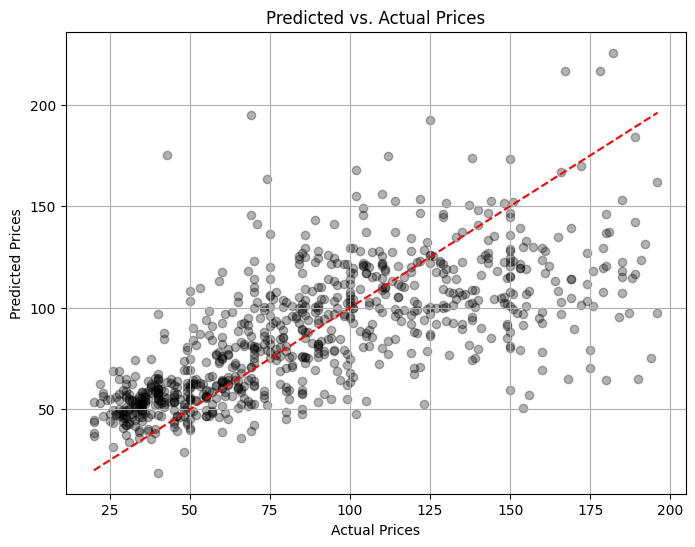

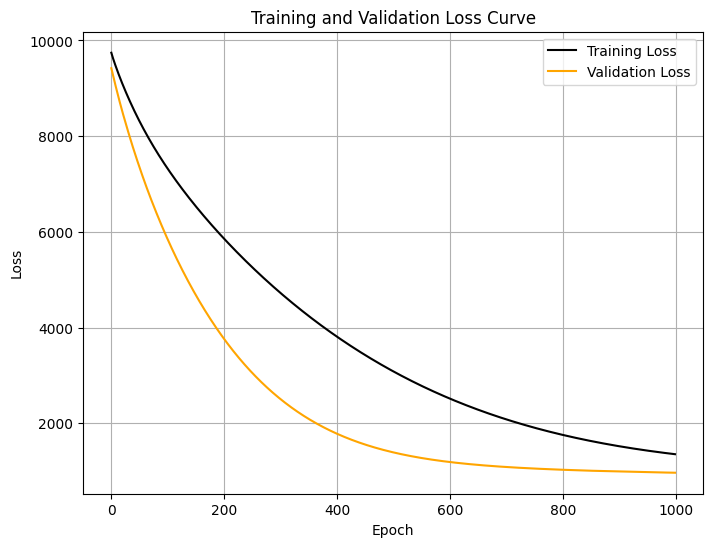

In [32]:
# CodeGrade Tag Q3d
## YOUR ANSWER HERE

model(clean_df, 'price', ['room_type'], learning_rate=0.5, epochs=1000, plots=True)

Input dimension:  , 37
Epoch [100/1000], Loss: 5935.2461
Epoch [200/1000], Loss: 3815.4934
Epoch [300/1000], Loss: 2536.1714
Epoch [400/1000], Loss: 1790.6672
Epoch [500/1000], Loss: 1379.7102
Epoch [600/1000], Loss: 1161.2617
Epoch [700/1000], Loss: 1044.1044
Epoch [800/1000], Loss: 977.1534
Epoch [900/1000], Loss: 935.1714
Epoch [1000/1000], Loss: 906.6952
Test Loss: 903.8598


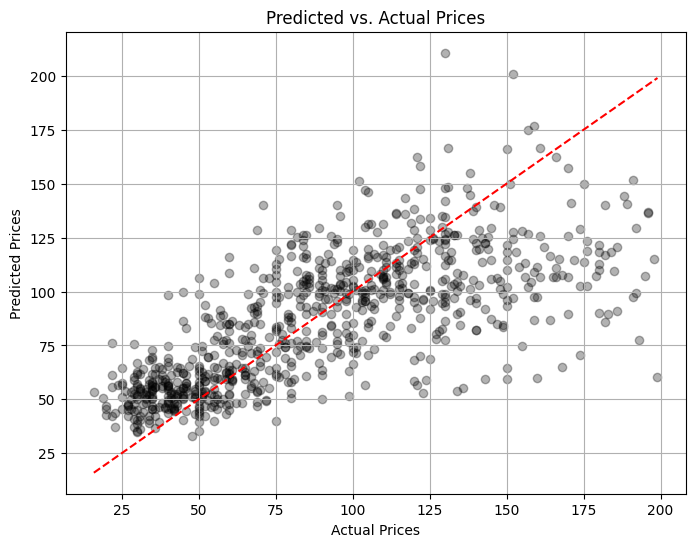

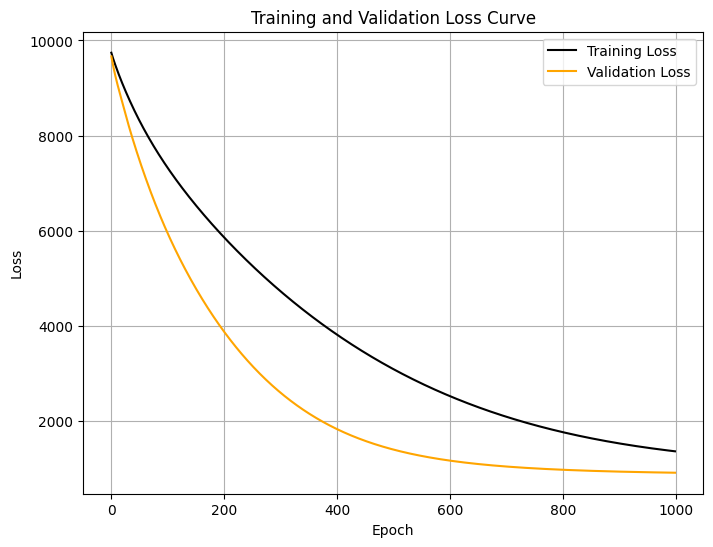

In [33]:
# CodeGrade Tag Q3e
## YOUR ANSWER HERE

model(clean_df, 'price', ['room_type'], learning_rate=0.01, epochs=1000, plots=True)

**Report Instructions 3.2 (9 marks)**

For each value of learning rate record whether the fit is improving or not relative to our original setup. Why do you think this might be?

**Exercise 3.4 (1 mark)**

Now let's add in another variable, the neighbourhood (which is for some reason called "neighbourhood_cleansed"). Add 'neighbourhood_cleansed' to the list of categorical columns, and set the learning rate to 0.05, and epochs to 2000.

Input dimension:  , 78
Epoch [100/1000], Loss: 4813.3594
Epoch [200/1000], Loss: 2524.8831
Epoch [300/1000], Loss: 1528.8107
Epoch [400/1000], Loss: 1133.5010
Epoch [500/1000], Loss: 975.2184
Epoch [600/1000], Loss: 900.4666
Epoch [700/1000], Loss: 857.6452
Epoch [800/1000], Loss: 830.4568
Epoch [900/1000], Loss: 812.5277
Epoch [1000/1000], Loss: 800.5190
Test Loss: 853.9199


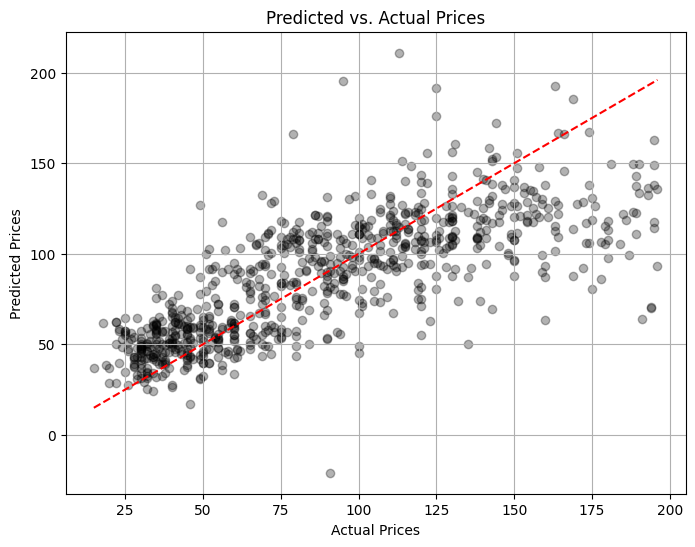

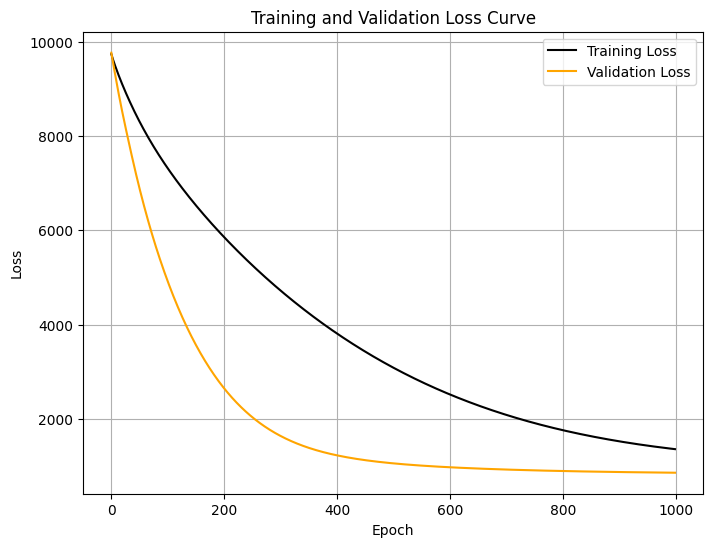

In [34]:
# CodeGrade Tag Q34
## YOUR ANSWER HERE

model(clean_df, 'price', ['room_type', 'neighbourhood_cleansed'], learning_rate=0.05, epochs=2000, plots=True)

The results are not yet useful - but they are encouraging....

Let's try a slightly different regression model.

# Q4 - Neural Net
**15 marks available for completing exercises 4.1, 4.2, 4.3, 4.4, 4.5 & 4.6** \\
**17 marks available for following report instructions 4.1, 4.2, 4.3, 4.4**

Below is an example of a simple neural network with three fully connected layers (fc1, fc2, fc3), and a function to combine the steps we applied above, now also taking a chosen neural net model as input. \\


The function takes an input as described below allowing you to update the categorical columns of interest, alter hyperparameters, and employ a neural net of your choice. \\



```
def model(df,     ## the dataframe of interest (dataframe object)
 label,           ## column name of the target variable (str)
 cat_cols,        ## list of categorical column names format: ['str', 'str', etc...]
 learning_rate,   ## step size at which the model parameters are updated during training (float)
 epochs,          ## number of iterations (float)
 nnmod,           ## Neural Net Model
 plots=True):     ## generate useful plots unless explicitly asked not to
```




In [35]:
## Define the neural network model (provided)
class NeuralNetworkModel1(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNetworkModel1, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [36]:
## (provided)
def nnmodel(df, label, cat_cols, learning_rate, epochs, nnmod, plots=True):

    df = df.dropna()

    ## Define features and target variable
    X = df.drop(columns=[str(label)])
    y = df[str(label)]

    ## Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    ## Define preprocessing steps for numerical and categorical features
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = cat_cols

    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    ## Preprocess the data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

    ## Convert preprocessed data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train_preprocessed, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
    X_test_tensor = torch.tensor(X_test_preprocessed, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)


    ## Instantiate the neural network model
    input_dim = X_train_tensor.shape[1]
    neural_network_model = nnmod(input_dim)

    print('')
    print('input_dim', input_dim)
    print('')

    ## Define loss function and optimization algorithm
    criterion = nn.MSELoss()
    optimizer = optim.Adam(neural_network_model.parameters(), lr=learning_rate)

    ## Train the model
    train_losses = []
    val_losses = []  # To track validation loss
    for epoch in range(epochs):
          # Training step
          optimizer.zero_grad()
          outputs = neural_network_model(X_train_tensor)
          loss = criterion(outputs, y_train_tensor)
          loss.backward()
          optimizer.step()
          train_losses.append(loss.item())

          # Validation step
          with torch.no_grad():
              val_outputs = neural_network_model(X_test_tensor)
              val_loss = criterion(val_outputs, y_test_tensor)
              val_losses.append(val_loss.item())

          if (epoch+1) % 100 == 0:
              print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}')



    ## Evaluate the model
    with torch.no_grad():
        predicted_prices = neural_network_model(X_test_tensor)
        test_loss = criterion(predicted_prices, y_test_tensor)
        print(f'Test Loss: {test_loss.item():.4f}')

    if plots:
        ## Convert tensors to numpy arrays
        predicted_prices = predicted_prices.numpy()
        actual_prices = y_test_tensor.numpy()

        ## Create scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(actual_prices, predicted_prices, alpha=0.2, c='navy')
        plt.plot([min(actual_prices), max(actual_prices)], [min(actual_prices), max(actual_prices)], color='darkred', linestyle='--')
        plt.xlabel('Actual Prices')
        plt.ylabel('Predicted Prices')
        plt.title('Predicted vs. Actual Prices')
        plt.grid(True)
        plt.show()

        ## Training and validation loss curve
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Training Loss', color='navy')
        plt.plot(val_losses, label='Validation Loss', color='orange', ls='--')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curve')
        plt.legend()
        plt.grid(True)
        plt.show()


Below is an example of how to call the nnmodel function.


input_dim 78

Epoch [100/500], Training Loss: 9021.0107, Validation Loss: 8752.3896
Epoch [200/500], Training Loss: 5053.2749, Validation Loss: 4848.3555
Epoch [300/500], Training Loss: 1681.7437, Validation Loss: 1714.8551
Epoch [400/500], Training Loss: 1251.6854, Validation Loss: 1306.5540
Epoch [500/500], Training Loss: 1069.3263, Validation Loss: 1146.1230
Test Loss: 1146.1230


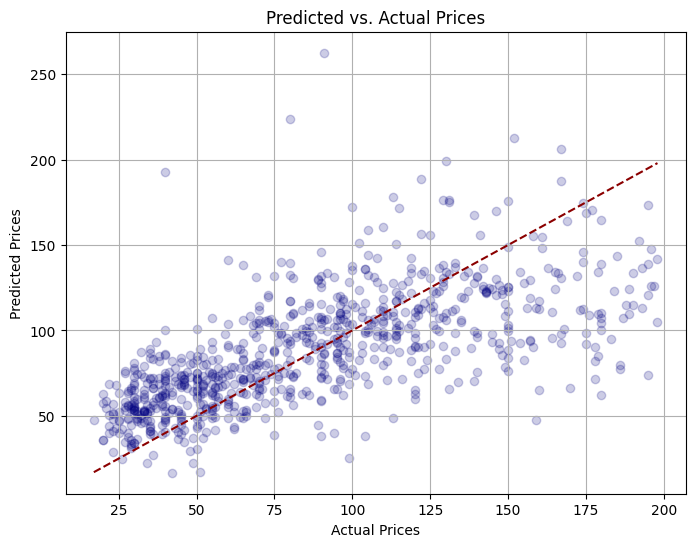

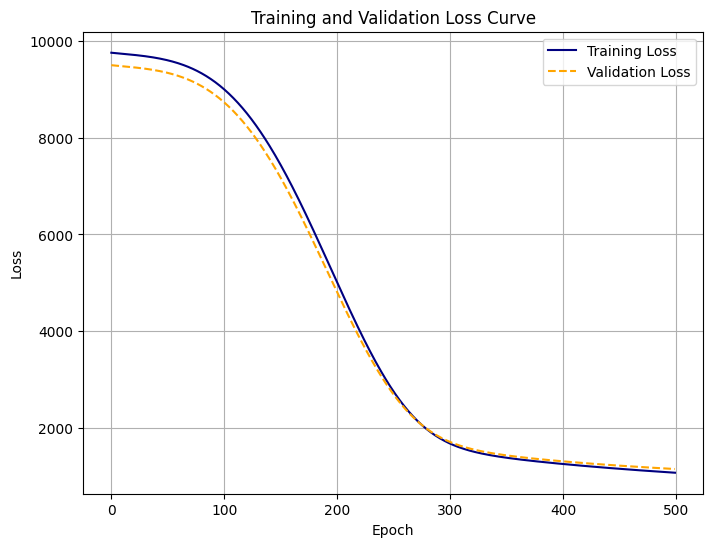

In [37]:
## Provided
nnmodel(clean_df, "price", ['room_type', 'neighbourhood_cleansed'], learning_rate=0.0005, epochs=500, nnmod=NeuralNetworkModel1)

**Report Instructions 4.1 (2 marks)**

Notice that our input dimensions = 65. But we only input 32 columns. Why might this be? Hint: think about the categorical variables.

**Exercise 4.1 (2 marks):** Copy the NeuralNetworkModel class from above into the code box below. Update the class to be called "NeuralNetworkModel2", and add another two layers to the network. In the code box below that, call the nnmod function passing in your new neural net. If you don't get a regression line passing through the data points at first, try a few different hyperparameters until you do. \\

In [38]:
# CodeGrade Tag Q4a
## Define a neural network model with 5 layers
## YOUR ANSWER HERE

class NeuralNetworkModel2(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNetworkModel2, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2=  nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return x


input_dim 78

Epoch [100/500], Training Loss: 9385.0439, Validation Loss: 9106.5742
Epoch [200/500], Training Loss: 1910.9812, Validation Loss: 1891.7793
Epoch [300/500], Training Loss: 1189.3960, Validation Loss: 1242.7937
Epoch [400/500], Training Loss: 974.1524, Validation Loss: 1063.3737
Epoch [500/500], Training Loss: 845.7918, Validation Loss: 955.6351
Test Loss: 955.6351


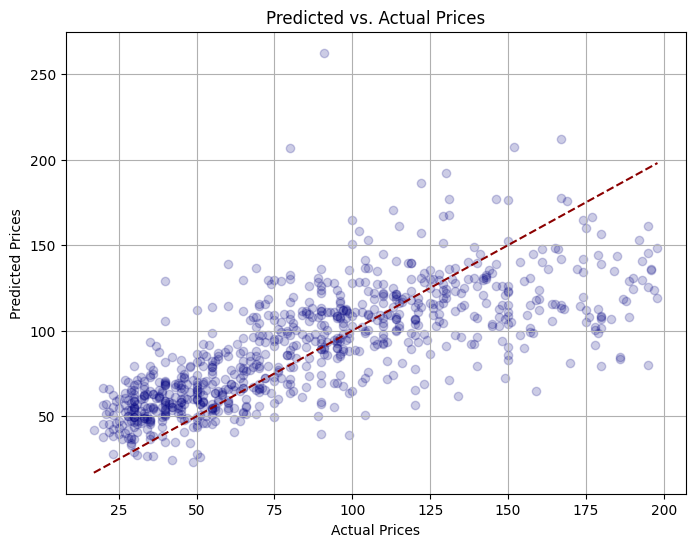

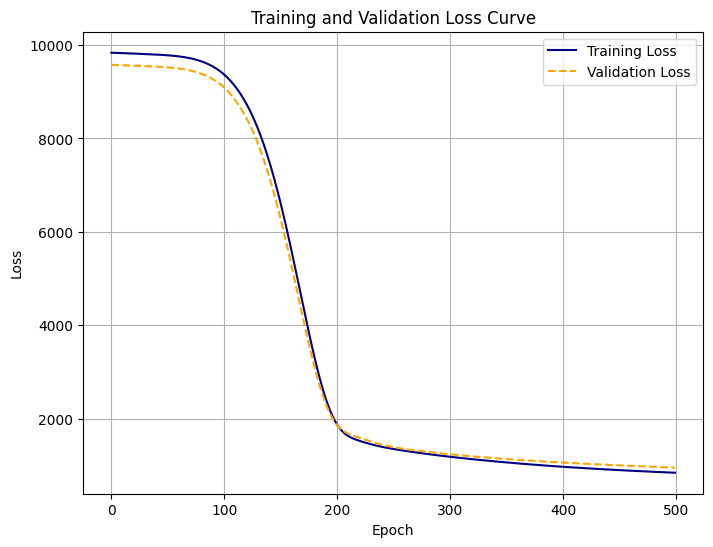

In [39]:
# CodeGrade Tag Q4b
## Call the nnmodel function passing in your new neural net
## YOUR ANSWER HERE

nnmodel(clean_df, "price", ['room_type', 'neighbourhood_cleansed'], learning_rate=0.0005, epochs=500, nnmod=NeuralNetworkModel2)

## More neurons

**Exercise 4.2 (1 mark)**

Copy the NeuralNetworkModel class from above into the code box below. Update the class to be called "NeuralNetworkModel3", use four layers and boost the number of neurons in the first layer to (input_dim, 256), then second (256, 128), third (128,64), and finally (64, 1).

**Report Instructions 4.2 (2 marks)**

Why must the final layer for this problem always include a single dimension?

In [40]:
# CodeGrade Tag Q42
## Define the neural network model with additional neurons
## YOUR ANSWER HERE

class NeuralNetworkModel3(nn.Module):
    def __init__(self, input_dim):
        super(NeuralNetworkModel3, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4=  nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x


## GPUs to the rescue

You might have noticed that the models were beginning to take some time to run. If you haven't done so already, update the runtime to use "T4 GPU".

**Exercise 4.3 (1 mark)**

Use the function provided below to run "NeuralNetworkModel3" using the GPUs. Alter your hyperparameters until the line goes through the data at least. \\


(Note, if no GPUs are available you can continue with a CPU, it will just be slower :)).

In [41]:
## (provided)

import math

def gpumodel(df, label, cat_cols, learning_rate, epochs, nnmod, plots=True):

    #CA: add a dropna
    df = df.dropna()

    ## Define features and target variable
    X = df.drop(columns=[str(label)])
    y = df[str(label)]

    ## Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    ## Define preprocessing steps for numerical and categorical features
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = cat_cols

    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    ## Preprocess the data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)

      #check x and y train for nans
    print("NAN CHECK")
    print(np.isnan(X_train_preprocessed).sum())
    print(np.isnan(y_train.values).sum())


    ## Convert preprocessed data to PyTorch tensors and move them to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train_tensor = torch.tensor(X_train_preprocessed, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)
    X_test_tensor = torch.tensor(X_test_preprocessed, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1).to(device)

    ## Instantiate the neural network model and move it to GPU
    input_dim = X_train_tensor.shape[1]
    neural_network_model = nnmod(input_dim).to(device)

    ## Define loss function and optimization algorithm
    criterion = nn.MSELoss()
    # Define the Mean Absolute Error (MAE) loss function using L1Loss
    criterion = nn.L1Loss()
    optimizer = optim.Adam(neural_network_model.parameters(), lr=learning_rate)

    ## Train the model
    train_losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = neural_network_model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(neural_network_model.parameters(), max_norm=1.0)

        optimizer.step()
        ## Track training loss
        train_losses.append(loss.item())
        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    ## Evaluate the model
    with torch.no_grad():
        predicted_prices = neural_network_model(X_test_tensor)
        test_loss = criterion(predicted_prices, y_test_tensor)
        print(f'Test Loss: {test_loss.item():.4f}')

    if plots:
        ## Convert tensors to numpy arrays
        predicted_prices = predicted_prices.cpu().numpy()
        actual_prices = y_test_tensor.cpu().numpy()

        ## Create scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(actual_prices, predicted_prices, alpha=0.5)
        plt.plot([min(actual_prices), max(actual_prices)], [min(actual_prices), max(actual_prices)], color='red', linestyle='--')
        plt.xlabel('Actual Prices')
        plt.ylabel('Predicted Prices')
        plt.title('Predicted vs. Actual Prices')
        plt.grid(True)
        plt.show()

        ## Training loss curve
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.legend()
        plt.grid(True)
        plt.show()



NAN CHECK
0
0
Epoch [100/500], Loss: 42.4101
Epoch [200/500], Loss: 19.3874
Epoch [300/500], Loss: 17.9804
Epoch [400/500], Loss: 16.8599
Epoch [500/500], Loss: 15.5054
Test Loss: 20.1133


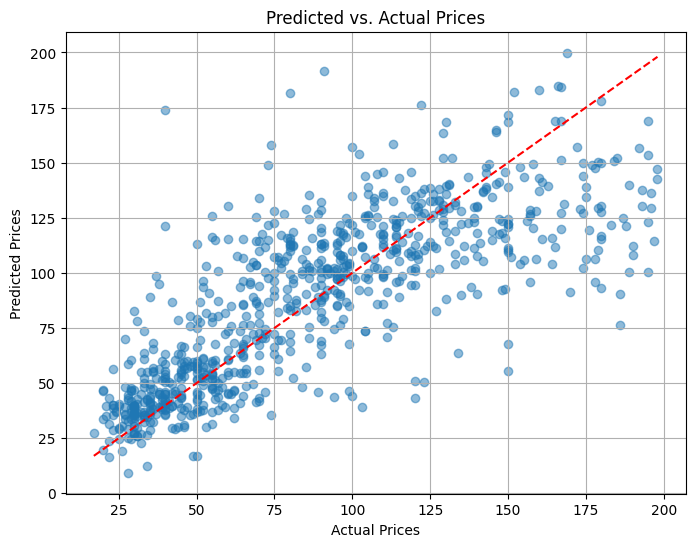

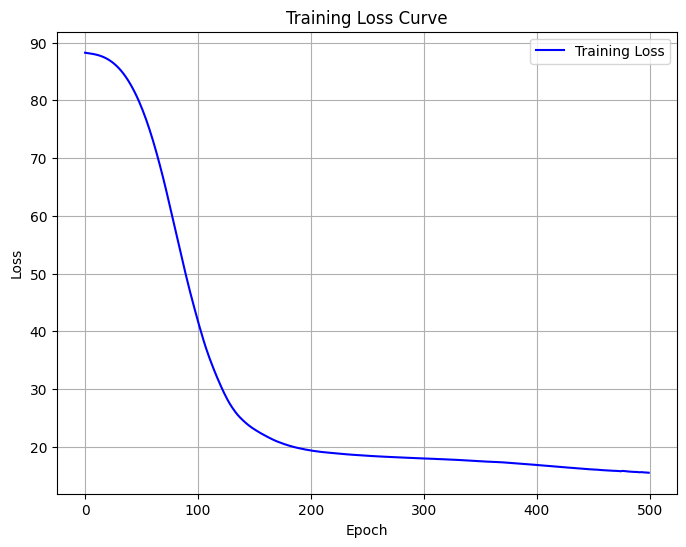

In [42]:
# CodeGrade Tag Q4c
## YOUR ANSWER HERE

gpumodel(clean_df, "price", ['room_type', 'neighbourhood_cleansed'], learning_rate=0.0005, epochs=500, nnmod=NeuralNetworkModel3)

## Bathrooms

We have so far neglected an important part of pricing. Bathrooms! In week 6 and 7 we developed a function to interpret the categorical data column "bathrooms_text" instead as two numerical columns "shared_bathrooms" and "private_bathrooms". Our function is pasted below.

**Exercise 4.4 (2 marks)**

Apply the "get_bathrooms" function to your clean dataframe, and call the returned dataframe "bathrmsdf". Display the first few lines of bathrmsdf, and then display the column headings and their Dtypes.

In [43]:
## (provided)
def get_bathrooms(df):

  ## pass it an already clean df with no nans!
  ## Function to split the 'bathrooms_text' column

  def split_bathrooms_text(row):
      if 'shared' in row['bathrooms_text']:
          row['shared_bathrooms'] = float(row['bathrooms_text'].split()[0]) if any(char.isdigit() for char in row['bathrooms_text']) else None
          row['private_bathrooms'] = 0
      else:
          row['shared_bathrooms'] = 0
          row['private_bathrooms'] = float(row['bathrooms_text'].split()[0]) if any(char.isdigit() for char in row['bathrooms_text']) else None
      return row

  ## Apply the function to each row
  df[['shared_bathrooms', 'private_bathrooms']] = df.apply(split_bathrooms_text, axis=1)[['shared_bathrooms', 'private_bathrooms']]

  ## Define the list of columns to check for NaN values
  columns_to_check = ['shared_bathrooms', 'private_bathrooms']

  ## Drop rows with NaN values in the specified columns
  df = df.dropna(subset=columns_to_check)

  ## Drop rows with no bathrooms
  df = df[(df['shared_bathrooms'] != 0) | (df['private_bathrooms'] != 0)]

  return df

In [44]:
# CodeGrade Tag Q4e
## Apply the "get_bathrooms" function to your clean dataframe, and call the returned dataframe "bathrmsdf"
## YOUR ANSWER HERE

bathrmsdf = get_bathrooms(clean_df)

In [45]:
# CodeGrade Tag Q4f
## Display the first few lines of bathrmsdf...
## YOUR ANSWER HERE

bathrmsdf.head()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,...,review_scores_accuracy,review_scores_checkin,review_scores_communication,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,shared_bathrooms,private_bathrooms
0,766050787596406053,20231223055521,486290053,17,20,Gorton South,53.446580,-2.19012,Private room,2,...,5.00,4.50,4.50,4.50,17,2,15,0,0.0,1.0
1,847143003204121734,20231223055521,419859842,9,19,Salford District,53.480290,-2.26835,Entire home/apt,3,...,4.33,4.78,4.89,4.11,9,6,2,1,0.0,1.0
2,5544328,20231223055521,26836949,23,31,Salford District,53.484530,-2.25691,Entire home/apt,4,...,4.80,4.87,4.93,4.67,6,6,0,0,0.0,2.0
3,42147825,20231223055521,86393358,3,9,Salford District,53.502200,-2.26850,Private room,2,...,4.88,4.88,4.94,4.65,3,0,3,0,1.5,0.0
4,995685793625080683,20231223055521,518896546,2,2,Salford District,53.475031,-2.27219,Private room,2,...,5.00,5.00,5.00,5.00,2,0,2,0,0.0,1.0


In [46]:
# CodeGrade Tag Q4g
## ...and then display the column headings and their Dtypes.
## YOUR ANSWER HERE

bathrmsdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 0 to 4052
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3999 non-null   int64  
 1   scrape_id                                     3999 non-null   int64  
 2   host_id                                       3999 non-null   int64  
 3   host_listings_count                           3999 non-null   int64  
 4   host_total_listings_count                     3999 non-null   int64  
 5   neighbourhood_cleansed                        3999 non-null   object 
 6   latitude                                      3999 non-null   float64
 7   longitude                                     3999 non-null   float64
 8   room_type                                     3999 non-null   object 
 9   accommodates                                  3999 non-null   int64 

**Exercise 4.5 (1 mark)**

Apply the gpumodel to bathrmsdf using NeuralNetworkModel3.

NAN CHECK
0
0
Epoch [100/500], Loss: 32.0724
Epoch [200/500], Loss: 18.5530
Epoch [300/500], Loss: 17.3377
Epoch [400/500], Loss: 16.1807
Epoch [500/500], Loss: 14.9700
Test Loss: 19.6977


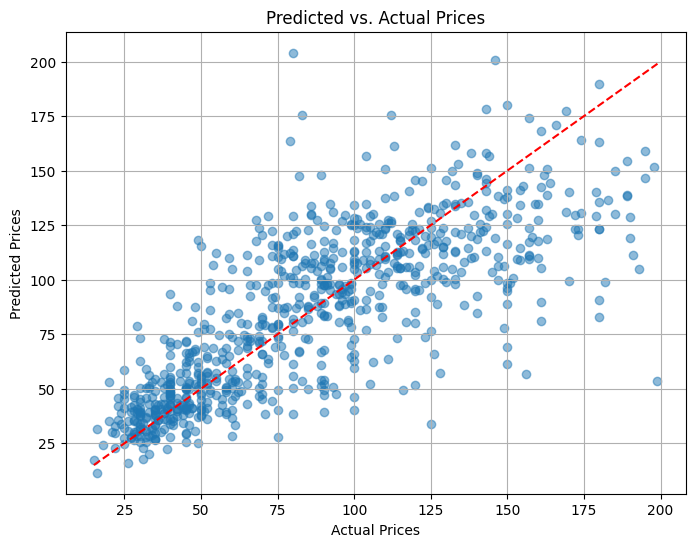

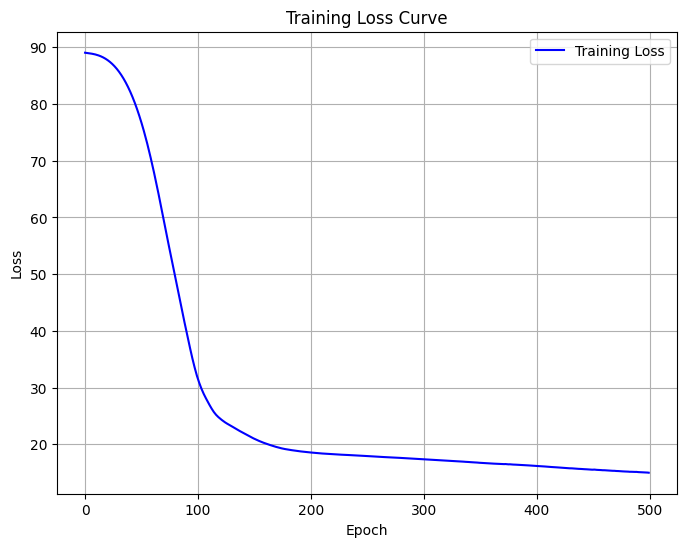

In [47]:
# CodeGrade Tag Q45
## Apply the gpumodel to bathrmsdf using NeuralNetworkModel3.
## YOUR ANSWER HERE

gpumodel(bathrmsdf, "price", ['room_type', 'neighbourhood_cleansed'], learning_rate=0.0005, epochs=500, nnmod=NeuralNetworkModel3)

**Report Instructions 4.3 (4 marks)**

Was this model any more successful? How can you tell? Why do you think this was?


**Exercise 4.6 (8 marks)**

Use histograms to examine the distribution of "shared_bathrooms" and "private_bathrooms". Are there any outliers? ... and what if you use a log scale on the y axis? (Note: usual rules about axis labels apply!). \\

Choose a sensible value as the upper limit for number of bathrooms to consider in your model. Drop rows from bathrmsdf that are over this limit in either column. Re-run the gpumodel on bathrmsdf using NeuralNetworkModel3. \\

CHECK THE TAGS BELOW CAREFULLY AND ANSWER THE RELEVANT PART OF THE QUESTION IN EACH BOX - YOU MAY ALSO ADD ADDITIONAL BOXES TO EXPERIMENT WITH THE DATA - Note - outlier function should be defined in one of the lower boxes (Q4l) and run in Q4m. \\

**Report Instructions 4.4 (9 marks)**

Record each step you have taken in the Assignment in your report. Include at the end a short discussion of the factors affecting the success or failure of the final model. What might the next steps you take be to refine the price prediction model? \\


(0.0, 6.0)

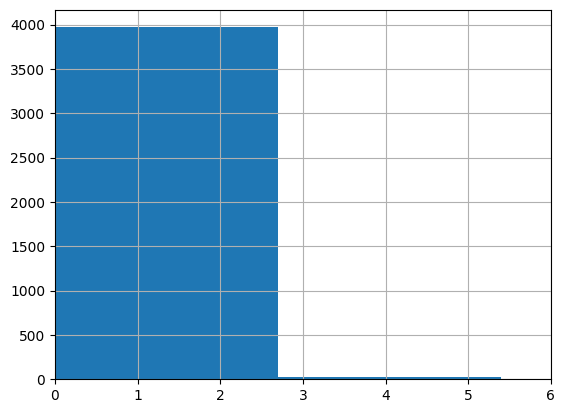

In [48]:
# CodeGrade Tag Q4h
## Examine the distribution of "shared_bathrooms"
## YOUR ANSWER HERE

bathrmsdf['shared_bathrooms'].hist(bins=10)
plt.xlim(0, 6)

<Axes: >

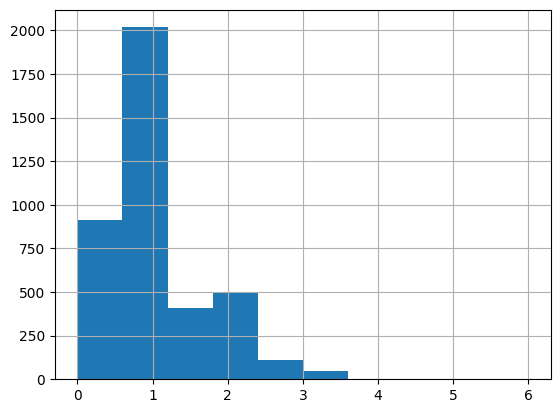

In [49]:
# CodeGrade Tag Q4i
## Examine the distribution of "private_bathrooms"
## YOUR ANSWER HERE

bathrmsdf['private_bathrooms'].hist(bins = 10)

In [ ]:
# CodeGrade Tag Q4j
## Choose a sensible value as the upper limit for number of bathrooms to consider in your model.
## Drop rows from bathrmsdf that are over this limit in either column.
## YOUR ANSWER HERE



In [ ]:
# CodeGrade Tag Q4k
## Re-run the gpumodel on bathrmsdf using NeuralNetworkModel3.
## YOUR ANSWER HERE



In [ ]:
# CodeGrade Tag Q4l
## Define a find_outlier function; hint: week 8
## YOUR ANSWER HERE



In [ ]:
# CodeGrade Tag Q4m
## run the find_outlier function as many times as you like here
## YOUR ANSWER HERE



In [ ]:
## Can use additional boxes below here to experiment....